<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/machine_learning/lab%206%20-%20XGBoost%20and%20Gradient%20Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost and Gradient Boosting

**Theory:** [notes/machine_learning/07_bagging_random_forest_boosting](https://imagra93.github.io/ML-course-labs/notes/machine_learning/07_bagging_random_forest_boosting.html) (bagging vs. boosting, AdaBoost, gradient boosting as gradient descent in function space). This lab builds the intuition with plots, compares AdaBoost with gradient boosting, and then uses XGBoost in practice.

**Boosting** adds many small trees one after another. Each new tree is fitted to what the current model still gets wrong, and is added with a small weight $\eta$ (the learning rate):

$$F_T(\mathbf{x}) = F_0 + \eta \sum_{t=1}^{T} f_t(\mathbf{x})$$

**XGBoost** (Chen & Guestrin, 2016) is a fast, regularised implementation of gradient boosting. Compared with plain gradient boosting it penalises big trees and large leaf values, uses the curvature of the loss to choose leaf values, and handles missing values and large datasets efficiently.

Contents:
1. Gradient boosting from scratch on a toy problem
2. AdaBoost from scratch, and how it differs from gradient boosting
3. Regression (Diabetes)
4. Binary classification (Breast Cancer), with AdaBoost, gradient boosting and XGBoost side by side
5. Multiclass classification (Wine)
6. Cross-validation and hyperparameter search
7. Learning rate, number of trees and early stopping
8. Feature importance
9. Feature selection: drop the weakest feature while cross-validation holds

Useful links: [XGBoost documentation](https://xgboost.readthedocs.io/en/latest/index.html), [parameters](https://xgboost.readthedocs.io/en/latest/parameter.html), [Python package](https://xgboost.readthedocs.io/en/latest/python/python_intro.html).

In [1]:
!pip3 install --upgrade xgboost

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint

from sklearn.datasets import load_breast_cancer, load_diabetes, load_wine, make_moons
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, mean_squared_error,
                             r2_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (cross_val_score, KFold, RandomizedSearchCV,
                                     StratifiedKFold, train_test_split)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

import xgboost as xgb

plt.style.use('seaborn-v0_8-whitegrid')
print(f"xgboost version: {xgb.__version__}")

xgboost version: 3.4.1


## 1. Gradient boosting from scratch

A 1D toy problem makes boosting easy to see. With squared loss, the "error to correct" is just the residual $y - F(x)$ (see notes 07, section 12).

In code:
1. Start with a constant prediction $F_0 = \text{mean}(y)$.
2. Compute the residuals $r = y - F$.
3. Fit a small tree (depth 2) to the residuals.
4. Update $F \leftarrow F + \eta \cdot \text{tree}(x)$ and repeat from step 2.

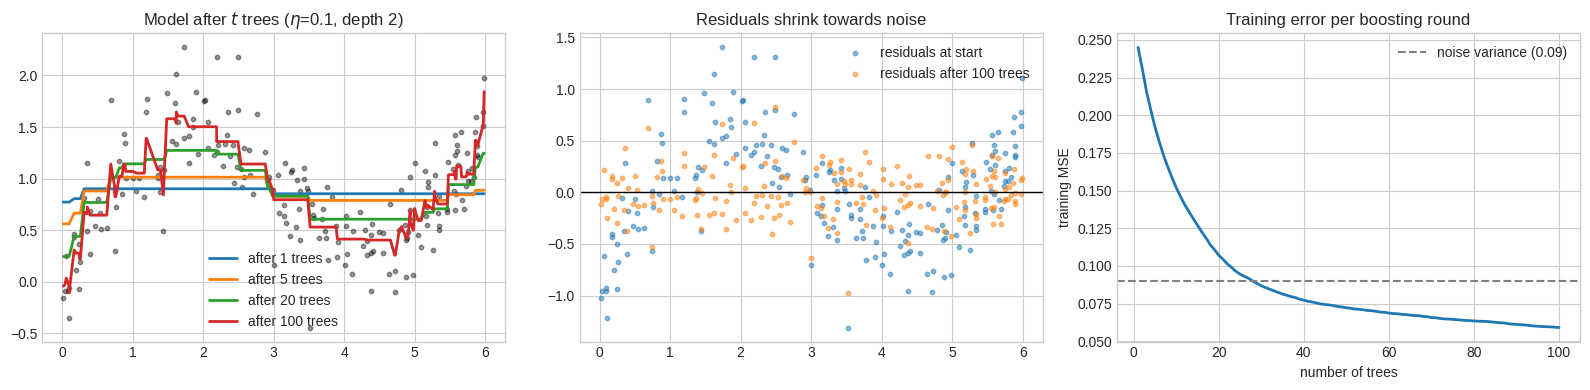

In [3]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 6, 200))
y = np.sin(x) + 0.3 * x + rng.normal(0, 0.3, 200)
X_toy = x[:, None]                        # sklearn/xgboost expect a 2D array

eta, n_trees = 0.1, 100
F = np.full_like(y, y.mean())             # step 1: constant start
snapshots, train_mse = {}, []

for t in range(1, n_trees + 1):
    residuals = y - F                                              # step 2
    tree = DecisionTreeRegressor(max_depth=2).fit(X_toy, residuals)  # step 3
    F = F + eta * tree.predict(X_toy)                              # step 4
    train_mse.append(np.mean((y - F) ** 2))
    if t in (1, 5, 20, 100):
        snapshots[t] = F.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: the model after more and more trees
axes[0].scatter(x, y, s=10, color='k', alpha=0.4)
for t, F_t in snapshots.items():
    axes[0].plot(x, F_t, lw=2, label=f'after {t} trees')
axes[0].set_title(rf'Model after $t$ trees ($\eta$={eta}, depth 2)')
axes[0].legend()

# Middle: residuals at the start vs. at the end
axes[1].scatter(x, y - y.mean(), s=10, alpha=0.5, label='residuals at start')
axes[1].scatter(x, y - F, s=10, alpha=0.5, label=f'residuals after {n_trees} trees')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_title('Residuals shrink towards noise')
axes[1].legend()

# Right: training error per round
axes[2].plot(range(1, n_trees + 1), train_mse, lw=2)
axes[2].axhline(0.3 ** 2, color='gray', ls='--', label='noise variance (0.09)')
axes[2].set_xlabel('number of trees'); axes[2].set_ylabel('training MSE')
axes[2].set_title('Training error per boosting round')
axes[2].legend()

plt.tight_layout()
plt.show()

Each tree only fixes a small part of the error, so the curve gets closer to the data step by step. After about 30 trees the training MSE drops below the noise variance (dashed line): the model has started fitting the noise, so the number of trees must be chosen with a validation set (section 7).

XGBoost does the same loop. For squared loss, the value it puts in a leaf is roughly

$$w = \frac{\text{sum of residuals in the leaf}}{\text{number of samples in the leaf} + \lambda}$$

that is, the mean residual shrunk towards 0 by the L2 penalty $\lambda$ (`reg_lambda`, default 1). Splits that improve the loss by less than $\gamma$ (`gamma`) are not made. With the same settings it gives almost the same fit as our loop:

In [4]:
xgb_toy = xgb.XGBRegressor(n_estimators=n_trees, learning_rate=eta, max_depth=2)
xgb_toy.fit(X_toy, y)

print(f"From scratch training MSE: {train_mse[-1]:.4f}")
print(f"XGBoost      training MSE: {mean_squared_error(y, xgb_toy.predict(X_toy)):.4f}")

From scratch training MSE: 0.0590
XGBoost      training MSE: 0.0648


## 2. AdaBoost from scratch, and how it differs from gradient boosting

AdaBoost (notes 07, section 10) also adds small trees one after another, but it focuses on the mistakes in another way: instead of fitting the residuals, it **re-weights the training examples**. Labels are $y \in \{-1, +1\}$ and every weak learner is a stump that answers $h_t(\mathbf{x}) \in \{-1, +1\}$.

In code:
1. Start with equal weights $w_i = \frac1m$.
2. Fit a stump on the weighted data.
3. Compute its weighted error $\varepsilon_t = \sum_{\text{mistakes}} w_i$ and its vote $\alpha_t = \frac12\ln\frac{1-\varepsilon_t}{\varepsilon_t}$.
4. Re-weight: $w_i \leftarrow w_i\, e^{-\alpha_t\, y^{(i)} h_t(\mathbf{x}^{(i)})}$ (mistakes heavier, hits lighter), divide by the sum and go back to step 2.

The prediction is the weighted vote $H(\mathbf{x}) = \mathrm{sign}\big(\sum_t \alpha_t h_t(\mathbf{x})\big)$.

To see the difference we run it next to **gradient boosting with the log-loss**, on the same 2D points and with the same stumps. It is the loop of section 1 with labels $y \in \{0, 1\}$: the model is a score $F$, the probability is $p = \sigma(F)$, and the residual each tree fits is $y - p$ (notes 07, section 13).

AdaBoost round 1: 36 mistakes, eps = 0.180, alpha = 0.758
AdaBoost round 2: 57 mistakes, eps = 0.261, alpha = 0.522
AdaBoost round 3: 62 mistakes, eps = 0.248, alpha = 0.556

After 100 rounds   train acc   test acc
AdaBoost               0.925      0.877
Gradient boosting      0.910      0.884

Share carried by the top 10% of points after 100 rounds: AdaBoost 48% of the weight, gradient boosting 33% of the residual


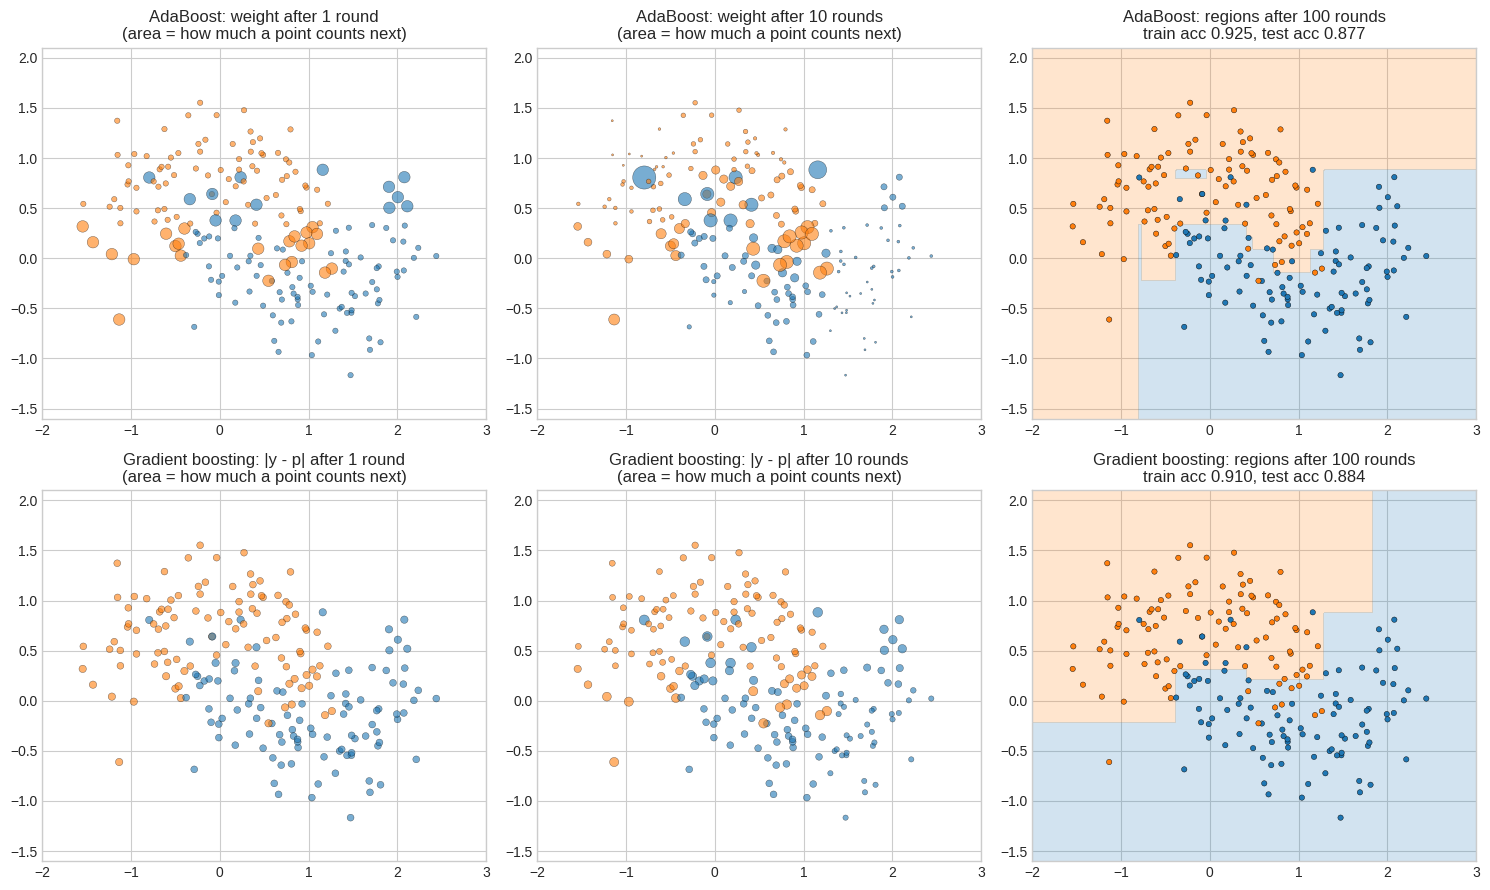

In [5]:
X2, y2 = make_moons(n_samples=200, noise=0.3, random_state=0)               # training points, labels 0/1
X2_test, y2_test = make_moons(n_samples=1000, noise=0.3, random_state=1)    # fresh points to test on
n_rounds = 100

# AdaBoost: labels -1/+1, the WEIGHTS change from round to round
y_pm = 2 * y2 - 1
w = np.full(len(y_pm), 1 / len(y_pm))                                      # step 1: equal weights
stumps, alphas, ada_weights = [], [], {}
for t in range(1, n_rounds + 1):
    stump = DecisionTreeClassifier(max_depth=1).fit(X2, y_pm, sample_weight=w)  # step 2
    h = stump.predict(X2)
    eps = w[h != y_pm].sum()                                                 # step 3: weighted error
    alpha = 0.5 * np.log((1 - eps) / eps)                                    #         and vote
    w = w * np.exp(-alpha * y_pm * h)                                        # step 4: re-weight
    w = w / w.sum()
    stumps.append(stump); alphas.append(alpha)
    if t <= 3:
        print(f"AdaBoost round {t}: {np.sum(h != y_pm)} mistakes, eps = {eps:.3f}, alpha = {alpha:.3f}")
    if t in (1, 10, n_rounds):
        ada_weights[t] = w.copy()

# Gradient boosting (log-loss): labels 0/1, the TARGETS (residuals) change from round to round
nu = 0.5
F0 = np.log(y2.mean() / (1 - y2.mean()))                                   # start: log-odds of the positive rate
F = np.full(len(y2), F0)
trees, gb_residuals = [], {}
for t in range(1, n_rounds + 1):
    residuals = y2 - 1 / (1 + np.exp(-F))                                    # y - p
    tree = DecisionTreeRegressor(max_depth=1).fit(X2, residuals)
    F = F + nu * tree.predict(X2)
    trees.append(tree)
    if t in (1, 10, n_rounds):
        gb_residuals[t] = np.abs(y2 - 1 / (1 + np.exp(-F)))                   # pull of each point on the next tree

def ada_score(X):                     # weighted vote; its sign is the class
    return sum(a * s.predict(X) for a, s in zip(alphas, stumps))

def gb_score(X):                      # log-odds; class 1 if positive
    return F0 + nu * sum(tr.predict(X) for tr in trees)

ada_acc = [np.mean((ada_score(A) > 0) == b) for A, b in [(X2, y2), (X2_test, y2_test)]]
gb_acc = [np.mean((gb_score(A) > 0) == b) for A, b in [(X2, y2), (X2_test, y2_test)]]
print(f"\nAfter {n_rounds} rounds   train acc   test acc")
print(f"AdaBoost               {ada_acc[0]:.3f}      {ada_acc[1]:.3f}")
print(f"Gradient boosting      {gb_acc[0]:.3f}      {gb_acc[1]:.3f}")

top = len(y2) // 10                   # the 10% points that count most
ada_share = np.sort(ada_weights[n_rounds])[-top:].sum()
gb_share = np.sort(gb_residuals[n_rounds])[-top:].sum() / gb_residuals[n_rounds].sum()
print(f"\nShare carried by the top 10% of points after {n_rounds} rounds: "
      f"AdaBoost {ada_share:.0%} of the weight, gradient boosting {gb_share:.0%} of the residual")

# Top row: AdaBoost weights; bottom row: gradient-boosting residuals; right: the final regions
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
gx, gy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.6, 2.1, 300))
grid = np.c_[gx.ravel(), gy.ravel()]
colors = np.where(y2 == 1, 'tab:blue', 'tab:orange')
for row, (name, pull, score, acc) in enumerate([
        ('AdaBoost: weight', ada_weights, ada_score, ada_acc),
        ('Gradient boosting: |y - p|', gb_residuals, gb_score, gb_acc)]):
    for col, t in enumerate((1, 10)):
        size = 25 * pull[t] / pull[t].mean()                                 # 25 = average point
        axes[row, col].scatter(X2[:, 0], X2[:, 1], s=size, c=colors, alpha=0.6, edgecolor='k', lw=0.3)
        axes[row, col].set_title(f'{name} after {t} round{"s" if t > 1 else ""}\n(area = how much a point counts next)')
    axes[row, 2].contourf(gx, gy, (score(grid) > 0).reshape(gx.shape), levels=[-0.5, 0.5, 1.5],
                          colors=['tab:orange', 'tab:blue'], alpha=0.2)
    axes[row, 2].scatter(X2[:, 0], X2[:, 1], s=15, c=colors, edgecolor='k', lw=0.3)
    axes[row, 2].set_title(f'{name.split(":")[0]}: regions after {n_rounds} rounds\n'
                           f'train acc {acc[0]:.3f}, test acc {acc[1]:.3f}')
for ax in axes.ravel():
    ax.set_xlim(-2, 3); ax.set_ylim(-1.6, 2.1)
plt.tight_layout()
plt.show()

Both methods end up looking at the same hard points, the ones near the border between the moons, and both draw an axis-aligned staircase (a stump cuts along one feature at a time). On new points they are about equally good. The difference is **how** each one focuses on the mistakes:

| | AdaBoost | Gradient boosting |
|---|---|---|
| What changes between rounds | the **weights** of the examples | the **targets**: each tree fits the residuals $y - p$ |
| Loss it minimises | exponential, $e^{-yF(\mathbf{x})}$ | any differentiable loss (squared error, log-loss, ...) |
| Size of each step | computed from the error: $\alpha_t$ | fixed: the learning rate $\nu$ |
| Weak learner | a classifier (the stump says $\pm1$) | a regression tree (the tree says a number) |
| Tasks | classification | regression, classification, ranking, ... |

The way a point gains influence is also different. Before the division by the sum, an AdaBoost weight is $e^{-yF(\mathbf{x})}$: it is multiplied by $e^{\alpha_t}$ every time the point is misclassified, so it can grow without limit, while a gradient-boosting residual $|y - p|$ can never be larger than 1. That is why AdaBoost concentrates more of its attention on the hardest points (the share printed above). Gradient boosting is also the more general recipe: any loss, any task. XGBoost, used in the rest of this lab, is a regularised and fast version of it.

scikit-learn has both: `AdaBoostClassifier` (stumps by default) and `GradientBoostingClassifier`. Section 4 compares them with XGBoost on real data.

## 3. Regression: Diabetes dataset

The [Diabetes dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) has 442 patients and 10 features (age, sex, BMI, blood pressure, 6 blood serum measurements). The target is a measure of disease progression one year later. We report RMSE (same units as the target) and $R^2$ (fraction of variance explained).

In [6]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
print(f"Samples: {X.shape[0]}, features: {X.shape[1]}")
print(f"Target range: [{y.min():.0f}, {y.max():.0f}]  (mean={y.mean():.1f})")
print(f"Feature names: {diabetes.feature_names}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=200,
                           learning_rate=0.1, max_depth=4, random_state=42)
xgb_reg.fit(X_train, y_train)

y_pred_train = xgb_reg.predict(X_train)
y_pred_test = xgb_reg.predict(X_test)

print(f"\nTrain RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.1f}   R2: {r2_score(y_train, y_pred_train):.3f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.1f}   R2: {r2_score(y_test, y_pred_test):.3f}")

Samples: 442, features: 10
Target range: [25, 346]  (mean=152.1)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Train RMSE: 11.5   R2: 0.978
Test  RMSE: 59.2   R2: 0.339


The training error is much lower than the test error: with 200 trees of depth 4 the model has memorised much of the training set. Sections 6 and 7 show how to choose the settings with cross-validation and early stopping.

## 4. Binary classification: Breast Cancer dataset

The [Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) has 569 samples and 30 features (measurements of cell nuclei). Target: malignant (0) or benign (1).

With `objective="binary:logistic"` the trees add up to a log-odds score $F(\mathbf{x})$, the predicted probability is $\sigma(F(\mathbf{x}))$, and the loss is the log-loss. Trees split on thresholds, so no feature scaling is needed.

Train accuracy: 1.000
Test  accuracy: 0.965
Test  ROC AUC : 0.994


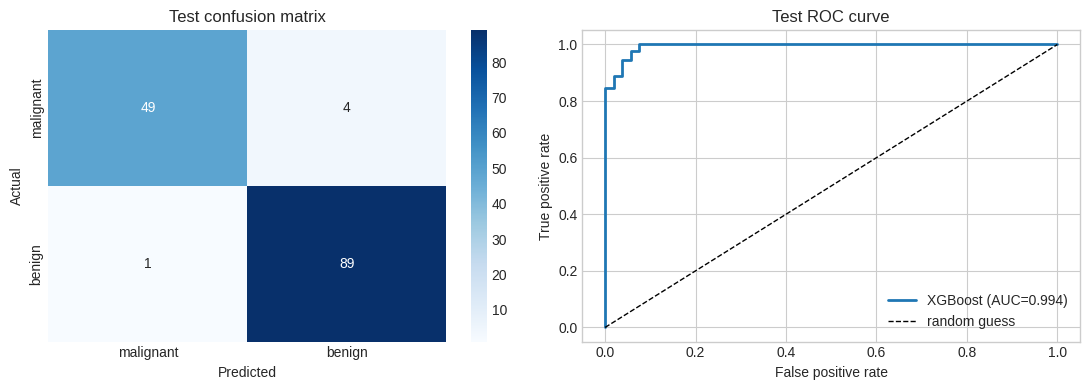

In [7]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

xgb_clf = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)                 # class labels
y_proba = xgb_clf.predict_proba(X_test)[:, 1]    # probability of class 1 (benign)

print(f"Train accuracy: {accuracy_score(y_train, xgb_clf.predict(X_train)):.3f}")
print(f"Test  accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test  ROC AUC : {roc_auc_score(y_test, y_proba):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix on the test set
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title('Test confusion matrix')

# ROC curve on the test set
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, lw=2, label=f'XGBoost (AUC={roc_auc_score(y_test, y_proba):.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='random guess')
ax2.set_xlabel('False positive rate'); ax2.set_ylabel('True positive rate')
ax2.set_title('Test ROC curve'); ax2.legend()

plt.tight_layout()
plt.show()

### AdaBoost, gradient boosting and XGBoost on the same data

The same breast cancer data with the three boosters, scored with 5-fold cross-validation (a single test set of 143 patients is too small to separate them): AdaBoost with 200 stumps, scikit-learn's gradient boosting with 200 trees of depth 3 (log-loss), and XGBoost with its defaults.

In [8]:
boosters = {
    "AdaBoost (stumps)": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=42),
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in boosters.items():
    scores = cross_val_score(model, X, y, cv=cv5)      # accuracy on each of the 5 folds
    print(f"{name:<18}  CV accuracy {scores.mean():.3f}  (std {scores.std():.3f})")

AdaBoost (stumps)   CV accuracy 0.967  (std 0.015)


Gradient boosting   CV accuracy 0.958  (std 0.024)
XGBoost             CV accuracy 0.963  (std 0.010)


The three scores differ by less than one standard deviation: on a small, clean dataset like this one the choice of booster matters less than its settings (sections 6 and 7). Gradient boosting is the usual choice in practice because it works with any loss (regression too) and, in XGBoost, comes with many regularisation knobs and early stopping.

## 5. Multiclass classification: Wine dataset

The [Wine dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) has 178 samples, 13 chemical features and 3 classes (grape cultivars).

With `objective="multi:softprob"` XGBoost grows one tree per class in each round, giving one score $F_k(\mathbf{x})$ per class, and turns the scores into probabilities with the softmax:
$$P(y=k \mid \mathbf{x}) = \frac{e^{F_k(\mathbf{x})}}{\sum_{j} e^{F_j(\mathbf{x})}}$$

Samples: 178, features: 13, classes: [0 1 2]


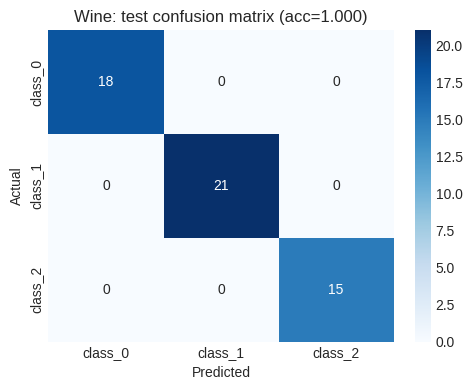

In [9]:
wine = load_wine()
X, y = wine.data, wine.target
print(f"Samples: {X.shape[0]}, features: {X.shape[1]}, classes: {np.unique(y)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

xgb_multi = xgb.XGBClassifier(objective="multi:softprob", random_state=42)
xgb_multi.fit(X_train, y_train)
y_pred = xgb_multi.predict(X_test)
acc = accuracy_score(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Wine: test confusion matrix (acc={acc:.3f})')
plt.tight_layout()
plt.show()

## 6. Cross-validation and hyperparameter search

One train/test split gives a noisy estimate. $k$-fold cross-validation trains and evaluates on $k$ different splits and averages the scores.

In [10]:
def display_scores(scores):
    """Print CV scores: individual folds, mean and std."""
    print(f"RMSE per fold: {np.round(scores, 1)}")
    print(f"Mean RMSE    : {np.mean(scores):.1f}  (std {np.std(scores):.1f})")

X, y = diabetes.data, diabetes.target
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
scores = -cross_val_score(xgb_reg, X, y, cv=kfold, scoring="neg_root_mean_squared_error")
display_scores(scores)

RMSE per fold: [59.6 63.8 53.6 71.5 74.6 66.2 63.6 70.4 64.3 63.9]
Mean RMSE    : 65.2  (std 5.7)


The main XGBoost hyperparameters:

| Parameter | What it controls |
|---|---|
| `n_estimators`, `learning_rate` | number of trees and the weight of each tree (tuned together, section 7) |
| `max_depth` | size of each tree |
| `subsample`, `colsample_bytree` | fraction of rows / features used per tree (adds randomness, like a random forest) |
| `reg_lambda`, `gamma` | penalty on leaf values / minimum loss reduction to make a split |

**Random search** samples settings from a distribution for each parameter. It usually finds good values with far fewer fits than a full grid. The score below is the default regression score, $R^2$ (higher is better).

In [11]:
def report_best_scores(results, n_top=3):
    """Print the top-n settings from a GridSearchCV / RandomizedSearchCV result."""
    for rank in range(1, n_top + 1):
        for i in np.flatnonzero(results['rank_test_score'] == rank):
            print(f"Rank {rank}: mean CV score {results['mean_test_score'][i]:.3f}"
                  f" (std {results['std_test_score'][i]:.3f})")
            params = {k: round(float(v), 3) if isinstance(v, float) else v for k, v in results['params'][i].items()}
            print(f"        params: {params}")

params = {
    "colsample_bytree": uniform(0.7, 0.3),   # 0.7 to 1.0
    "gamma": uniform(0, 0.5),
    "learning_rate": uniform(0.03, 0.3),     # 0.03 to 0.33
    "max_depth": randint(2, 6),              # 2 to 5
    "n_estimators": randint(100, 150),
    "subsample": uniform(0.6, 0.4),          # 0.6 to 1.0
}

search = RandomizedSearchCV(xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
                            param_distributions=params, n_iter=50, cv=3,
                            random_state=42, n_jobs=1)
search.fit(X, y)
report_best_scores(search.cv_results_, n_top=3)

Rank 1: mean CV score 0.466 (std 0.014)
        params: {'colsample_bytree': 0.79, 'gamma': 0.142, 'learning_rate': 0.041, 'max_depth': 2, 'n_estimators': 101, 'subsample': 0.801}
Rank 2: mean CV score 0.453 (std 0.020)
        params: {'colsample_bytree': 0.904, 'gamma': 0.225, 'learning_rate': 0.034, 'max_depth': 2, 'n_estimators': 113, 'subsample': 0.923}
Rank 3: mean CV score 0.434 (std 0.011)
        params: {'colsample_bytree': 0.722, 'gamma': 0.179, 'learning_rate': 0.065, 'max_depth': 4, 'n_estimators': 108, 'subsample': 0.849}


## 7. Learning rate, number of trees and early stopping

A smaller learning rate makes each tree count less, so more trees are needed, but the result often generalises a bit better. Too many trees overfit. We use the Diabetes data again, where overfitting is easy to see. **Early stopping** tracks a validation metric and stops when it has not improved for `early_stopping_rounds` rounds.

In code:
1. Split off a validation set.
2. Set a large `n_estimators` and pass `early_stopping_rounds` to the constructor.
3. Pass the validation set as `eval_set` to `fit()`; `evals_result()` returns the metric per round.

No early stopping: best val RMSE 53.1 at round 22, val RMSE after 300 rounds 57.6

learning_rate=0.3    best round:   8   best val RMSE: 53.7
learning_rate=0.1    best round:  22   best val RMSE: 53.1
learning_rate=0.03   best round:  78   best val RMSE: 53.2


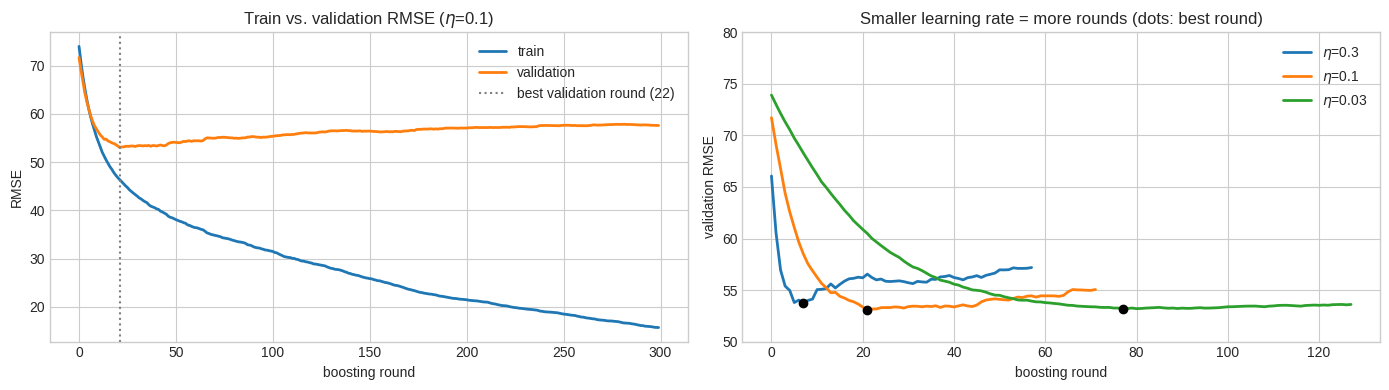

In [12]:
X, y = diabetes.data, diabetes.target
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

# One model without early stopping, to see the full train/validation curves
model_lc = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=300, learning_rate=0.1,
                            max_depth=3, eval_metric="rmse", random_state=42)
model_lc.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
curves = model_lc.evals_result()   # 'validation_0' = train set, 'validation_1' = validation set
val_rmse = curves['validation_1']['rmse']
best = int(np.argmin(val_rmse))
print(f"No early stopping: best val RMSE {val_rmse[best]:.1f} at round {best + 1}, "
      f"val RMSE after 300 rounds {val_rmse[-1]:.1f}\n")

# Several learning rates, each with early stopping
stopped = {}
for lr in [0.3, 0.1, 0.03]:
    m = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=2000, learning_rate=lr,
                         max_depth=3, eval_metric="rmse", early_stopping_rounds=50,
                         random_state=42)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    stopped[lr] = m
    print(f"learning_rate={lr:<5}  best round: {m.best_iteration + 1:3d}   best val RMSE: {m.best_score:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(curves['validation_0']['rmse'], lw=2, label='train')
ax1.plot(val_rmse, lw=2, label='validation')
ax1.axvline(best, color='gray', ls=':', label=f'best validation round ({best + 1})')
ax1.set_xlabel('boosting round'); ax1.set_ylabel('RMSE')
ax1.set_title(r'Train vs. validation RMSE ($\eta$=0.1)'); ax1.legend()

for lr, m in stopped.items():
    ax2.plot(m.evals_result()['validation_0']['rmse'], lw=2, label=rf'$\eta$={lr}')
    ax2.scatter(m.best_iteration, m.best_score, color='k', zorder=3)
ax2.set_ylim(50, 80)
ax2.set_xlabel('boosting round'); ax2.set_ylabel('validation RMSE')
ax2.set_title('Smaller learning rate = more rounds (dots: best round)'); ax2.legend()

plt.tight_layout()
plt.show()

The training error keeps falling while the validation error reaches a minimum after about 20 rounds and then rises: that is overfitting. Early stopping picks the round with the lowest validation error. A smaller learning rate needs more rounds to get there; on this small dataset all three reach a similar best RMSE.

After early stopping, `predict()` automatically uses the trees up to `best_iteration`. To train a final model on all the data (train + validation), use `n_estimators = best_iteration + 1`.

## 8. Feature importance

XGBoost can rank features by how often they are used in splits (`weight`), or by how much they reduce the loss on average (`gain`, usually more informative). Both are computed on training data and split the credit between correlated features; permutation importance on held-out data is more trustworthy (see notes 07, section 7).

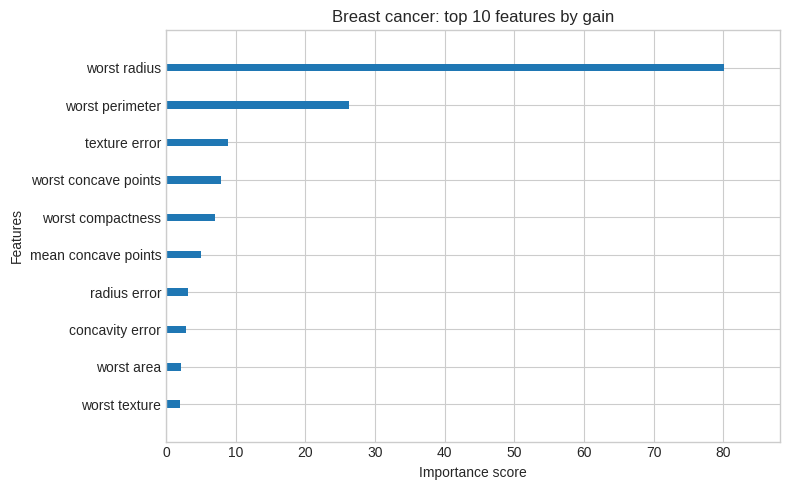

In [13]:
# The breast cancer classifier from section 4
xgb_clf.get_booster().feature_names = list(cancer.feature_names)   # readable labels in the plot

fig, ax = plt.subplots(figsize=(8, 5))
xgb.plot_importance(xgb_clf, ax=ax, importance_type='gain', max_num_features=10,
                    show_values=False, title='Breast cancer: top 10 features by gain')
plt.tight_layout()
plt.show()

## 9. Feature selection: drop the weakest feature while cross-validation holds

Fewer features make a model cheaper to run, cheaper to collect data for, and easier to explain. The importances of section 8 give a simple recipe, **backward elimination**:

1. Start with all the features and compute the CV score.
2. Fit the model, find the feature with the lowest importance and remove it.
3. Compute the CV score without it. If it falls by more than a small tolerance below the best score so far, **stop** and keep the previous set; otherwise go back to step 2.

Two details matter:
- The importances are **recomputed after every removal**. Correlated features share the credit (section 8), so when one of them goes, the importance of its partner rises.
- The **tolerance**. A CV score moves a little from noise alone: one more mistake in one fold of about 85 patients moves the 5-fold mean by 0.0024, and the standard error of the mean is about 0.01 here. Stopping at the first small drop would stop after a few features, by chance.

Everything is done on the training set of section 4; the test set is used only once, at the end.

In [14]:
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)  # same split as section 4

model = xgb.XGBClassifier(random_state=42)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tol = 0.01                                   # allowed drop in CV accuracy (about one standard error here)

features = list(range(X.shape[1]))           # column indices still in the model: all 30 at the start
best = cross_val_score(model, X_train, y_train, cv=cv5).mean()
history = [(len(features), best)]
print(f"start with {len(features)} features: CV accuracy {best:.4f}")
while len(features) > 1:
    importance = model.fit(X_train[:, features], y_train).feature_importances_   # gain, recomputed every round
    weakest = features[np.argmin(importance)]
    candidate = [f for f in features if f != weakest]
    score = cross_val_score(model, X_train[:, candidate], y_train, cv=cv5).mean()
    history.append((len(candidate), score))
    print(f"drop {cancer.feature_names[weakest]:<24} -> {len(candidate):2d} features: CV accuracy {score:.4f}")
    if score < best - tol:                   # cross-validation regressed: keep the previous set
        print(f"CV accuracy fell more than {tol} below the best ({best:.4f}): stop")
        break
    features, best = candidate, max(best, score)

start with 30 features: CV accuracy 0.9719
drop mean perimeter           -> 29 features: CV accuracy 0.9719


drop mean symmetry            -> 28 features: CV accuracy 0.9719
drop perimeter error          -> 27 features: CV accuracy 0.9695


drop worst fractal dimension  -> 26 features: CV accuracy 0.9719
drop concave points error     -> 25 features: CV accuracy 0.9672
drop mean concavity           -> 24 features: CV accuracy 0.9672


drop mean radius              -> 23 features: CV accuracy 0.9695
drop symmetry error           -> 22 features: CV accuracy 0.9695


drop mean area                -> 21 features: CV accuracy 0.9672
drop mean compactness         -> 20 features: CV accuracy 0.9743


drop smoothness error         -> 19 features: CV accuracy 0.9672
drop mean fractal dimension   -> 18 features: CV accuracy 0.9649
drop worst symmetry           -> 17 features: CV accuracy 0.9672


drop compactness error        -> 16 features: CV accuracy 0.9649
drop mean smoothness          -> 15 features: CV accuracy 0.9602
CV accuracy fell more than 0.01 below the best (0.9743): stop


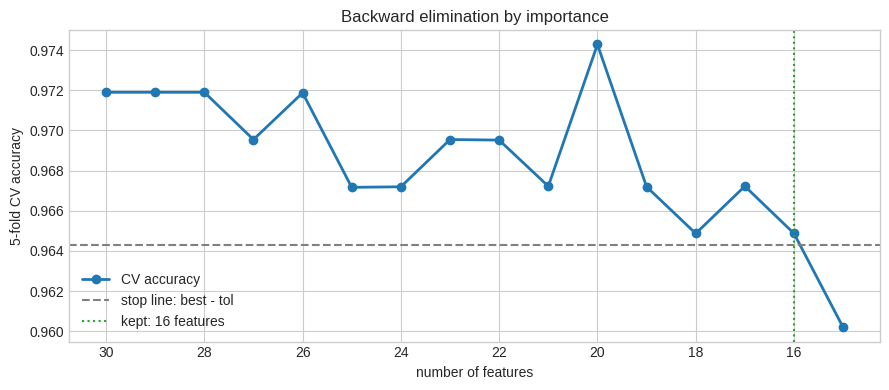

All 30 features : test accuracy 0.965
16 features  : test accuracy 0.965
kept: mean texture, mean smoothness, mean concave points, radius error, texture error, area error, concavity error, fractal dimension error, worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points


In [15]:
n_kept, cv_acc = zip(*history)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_kept, cv_acc, 'o-', lw=2, label='CV accuracy')
ax.axhline(best - tol, color='gray', ls='--', label='stop line: best - tol')
ax.axvline(len(features), color='tab:green', ls=':', label=f'kept: {len(features)} features')
ax.invert_xaxis()                            # read left to right: removing features
ax.set_xlabel('number of features'); ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Backward elimination by importance'); ax.legend()
plt.tight_layout()
plt.show()

full = xgb.XGBClassifier(random_state=42).fit(X_train, y_train)
small = xgb.XGBClassifier(random_state=42).fit(X_train[:, features], y_train)
print(f"All {X.shape[1]} features : test accuracy {full.score(X_test, y_test):.3f}")
print(f"{len(features)} features  : test accuracy {small.score(X_test[:, features], y_test):.3f}")
print("kept:", ", ".join(cancer.feature_names[features]))

16 of the 30 features give the same test accuracy as all 30: 0.965, that is 138 of the 143 test patients right. The dropped features were mostly redundant. The dataset measures 10 properties of the cell nuclei three times (mean, standard error and worst value): the loop removed the mean radius, perimeter and area, which have a correlation of 0.96–0.97 with their "worst" versions, and kept 8 of the 10 "worst" columns.

The path also shows why the tolerance is needed. From one step to the next the score moves up and down in steps of 0.0024 (one patient in one fold): with "stop at the first drop" the loop would have stopped at 28 features. The peak at 20 features is partly luck too, and it raised the stop line.

Two warnings:
- The CV score of the kept set is **optimistic**: the set was chosen by looking at those scores. Only the untouched test set gives an honest estimate.
- A low gain does not prove that a feature is useless: it may be redundant with another one that is still in the model. Permutation importance on held-out data (notes 07, section 7) is slower but more trustworthy.

scikit-learn's `RFECV` (recursive feature elimination with cross-validation) runs the same loop, but instead of stopping at the first big drop it scores every number of features and keeps the best one.